In [1]:
from sklearn.metrics import mean_squared_error
import random
import numpy as np
import pandas as pd


# Load and pre-process data

In [2]:
target_col = "log_average_ms"

node_cols = ["Abs", "Acos", "Add", "ai.onnx.ml::CategoryMapper", "And", "ArgMax", 
             "AveragePool", "BatchNormalization", "Cast", "Ceil", "Clip", 
             "com.microsoft::BiasGelu", "com.microsoft::DynamicQuantizeLSTM", 
             "com.microsoft::DynamicQuantizeMatMul", "com.microsoft::FastGelu", 
             "com.microsoft::FusedConv", "com.microsoft::FusedGemm", 
             "com.microsoft::FusedMatMul", "com.microsoft::MatMulIntegerToFloat", 
             "com.microsoft::QGemm", "com.microsoft::QLinearAdd", 
             "com.microsoft::QLinearAveragePool", "com.microsoft::QLinearConcat", 
             "com.microsoft::QLinearGlobalAveragePool", "com.microsoft::QLinearLeakyRelu", 
             "com.microsoft::QLinearMul", "com.microsoft::QLinearSigmoid", 
             "com.microsoft::QuickGelu", "com.microsoft::SkipLayerNormalization", 
             "Compress", "Concat", "Constant", "ConstantOfShape", "Conv", "ConvInteger", 
             "ConvTranspose", "Cos", "CumSum", "DequantizeLinear", "Div", "Dropout", 
             "DynamicQuantizeLinear", "Einsum", "Equal", "Erf", "Exp", "Expand", 
             "EyeLike", "Flatten", "Floor", "Gather", "GatherElements", "GatherND", 
             "Gelu", "Gemm", "GlobalAveragePool", "Greater", "GreaterOrEqual", "Hardmax", 
             "HardSigmoid", "HardSwish", "Identity", "If", "InstanceNormalization", 
             "LayerNormalization", "LeakyRelu", "Less", "LessOrEqual", "local::preprocess", 
             "Log", "LogSoftmax", "Loop", "LRN", "LSTM", "MatMul", "MatMulInteger", 
             "Max", "MaxPool", "Min", "Mod", "Mul", "Neg", "NonMaxSuppression", "NonZero", 
             "Not", "OneHot", "Or", "Pad", "Pow", "PRelu", "QLinearConv", "QLinearMatMul", 
             "QuantizeLinear", "Range", "Reciprocal", "ReduceMax", "ReduceMean", "ReduceMin", 
             "ReduceProd", "ReduceSum", "Relu", "Reshape", "Resize", "RoiAlign", "Round", 
             "Scan", "ScatterElements", "ScatterND", "Shape", "Sigmoid", 
             "SimplifiedLayerNormalization", "Sin", "Slice", "Softmax", "Split", "Sqrt", 
             "Squeeze", "Sub", "Sum", "Tanh", "Tile", "TopK", "Transpose", "Trilu", 
             "Unsqueeze", "Where", "Xor"]

model_feature_cols = node_cols + ["conv_flops", "matmul_flops",
                "elementwise_mb", "reduction_mb", "normalization_mb",
                "movement_mb", "memory_mb"]

hardware_feature_cols = ["l1d_cache_kb", "l1i_cache_kb", "l2_cache_kb", 
                         "base_clock_mhz", "num_cores", "memory_bandwith_gbs", 
                         "cpu_provider"]

metadata_cols = ["model", "cpu_provider",
                 "machine_type", "platform", "run_id"]

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

In [3]:
# load test, train, val sets

train_df = pd.read_csv("/content/drive/MyDrive/Data/train_set.csv")
val_df = pd.read_csv("/content/drive/MyDrive/Data/val_set.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Data/test_set.csv")

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

train: (100252, 154)
val: (21483, 154)
test: (21483, 154)


In [4]:
assert list(train_df.columns) == list(val_df.columns) == list(test_df.columns)

train_df.head()

,model,input_dimensions,input_dtypes,output_dimensions,output_dtypes,conv_flops,matmul_flops,elementwise_mb,reduction_mb,normalization_mb,...,base_clock_mhz,memory_bandwith_gbs,cpu_provider,machine_type,platform,repo_file,average_ms,stddev_ms,min_ms,max_ms
0,hardcorenas_d_Opset17_extended.onnx,x:1x3x224x224,x:float32,668:1x1000,668:float32,472440512,2560000,50.528229,5.204269,0.000000,...,2300.000,717,intel,xeon_plat,bluehive,hardcorenas_d_Opset17.onnx,14.069188,0.082284,13.931521,14.247209
1,vit_base_patch8_224_in21k_Opset17_disable_all....,x:1x3x224x224,x:float32,1089:1x21843,1089:float32,231211008,156097479168,1771.169711,0.000000,792.141724,...,2450.000,205,amd,epyc,gcloud,vit_base_patch8_224_in21k_Opset17.onnx,1481.456045,150.199862,1094.324125,1632.506909
2,tf_efficientnetv2_m_in21ft1k_Opset17_basic.onnx,x:1x3x384x384,x:float32,2466:1x1000,2466:float32,31470991360,2560000,1201.339462,67.736023,0.000000,...,2449.998,205,amd,epyc,gcloud,tf_efficientnetv2_m_in21ft1k_Opset17.onnx,301.127424,12.889699,286.464729,324.336829
3,shufflenet_v2_x1_5_Opset16.onnx,x:1x3x224x224,x:float32,1137:1x1000,1137:float32,266034528,2048000,8.246674,1.630875,0.000000,...,2449.998,205,amd,epyc,gcloud,shufflenet_v2_x1_5_Opset16.onnx,8.161246,0.036559,8.080030,8.197800
4,wide_resnet101_2_Opset16_timm.onnx,x:1x3x224x224,x:float32,971:1x1000,971:float32,45502005248,4096000,252.656250,4.218750,0.000000,...,2300.000,717,intel,xeon_plat,bluehive,wide_resnet101_2_Opset16_timm.onnx,38.147223,0.068437,38.035275,38.292409


In [5]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

SEED = 67
random.seed(SEED)
np.random.seed(SEED)

In [6]:
# pre-processing function

def preprocess(df: pd.DataFrame, train=False) -> pd.DataFrame:

  #drop rows with missing target
  df = df.dropna(subset=["average_ms"])

  # keep Run 6/10's strict CV rule on all splits
  cv_limit = 0.1
  df["cv"] = df["stddev_ms"] / df["average_ms"]
  df = df[df["cv"] <= cv_limit].copy()

  #add log_average_ms column
  df["log_average_ms"] = np.log(df["average_ms"])

  #remove decimals and round down
  for col in ["elementwise_mb", "reduction_mb", "normalization_mb", "movement_mb"]:
    df[col] = df[col].round(0)

  return df

In [7]:
train_df = preprocess(train_df, True)
test_df = preprocess(test_df, False)
val_df = preprocess(val_df, False)

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

train: (95814, 156)
val: (20494, 156)
test: (20528, 156)


In [8]:
for col in model_feature_cols:
    train_df[col] = np.log1p(train_df[col].clip(lower=0))
    val_df[col] = np.log1p(val_df[col].clip(lower=0))
    test_df[col] = np.log1p(test_df[col].clip(lower=0))

# Data Setup

In [9]:
target_col = "log_average_ms"

In [10]:
cpu_provider_map = {
    "intel": 0.0,
    "amd": 1.0,
}

for df in [train_df, val_df, test_df]:
    df["cpu_provider_binary"] = df["cpu_provider"].map(cpu_provider_map)

    if df["cpu_provider_binary"].isna().any():
        bad_values = df.loc[df["cpu_provider_binary"].isna(), "cpu_provider"].unique()
        raise ValueError(f"Unknown cpu_provider values: {bad_values}")

hardware_feature_cols = [
    col for col in hardware_feature_cols
    if col not in {"cpu_provider", "cpu_provider_binary"}
]
hardware_feature_cols.append("cpu_provider_binary")

/tmp/ipykernel_22789/3350037661.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["cpu_provider_binary"] = df["cpu_provider"].map(cpu_provider_map)
/tmp/ipykernel_22789/3350037661.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["cpu_provider_binary"] = df["cpu_provider"].map(cpu_provider_map)
/tmp/ipykernel_22789/3350037661.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using 

In [11]:
X_model_train = train_df[model_feature_cols].astype("float32").to_numpy()
X_model_val = val_df[model_feature_cols].astype("float32").to_numpy()
X_model_test = test_df[model_feature_cols].astype("float32").to_numpy()

X_hw_train = train_df[hardware_feature_cols].astype("float32").to_numpy()
X_hw_val = val_df[hardware_feature_cols].astype("float32").to_numpy()
X_hw_test = test_df[hardware_feature_cols].astype("float32").to_numpy()

y_train = train_df[target_col].astype("float32").to_numpy()
y_val = val_df[target_col].astype("float32").to_numpy()
y_test = test_df[target_col].astype("float32").to_numpy()

In [12]:
model_scaler = StandardScaler()
hw_scaler = StandardScaler()

X_model_train = model_scaler.fit_transform(X_model_train).astype("float32")
X_model_val = model_scaler.transform(X_model_val).astype("float32")
X_model_test = model_scaler.transform(X_model_test).astype("float32")

X_hw_train = hw_scaler.fit_transform(X_hw_train).astype("float32")
X_hw_val = hw_scaler.transform(X_hw_val).astype("float32")
X_hw_test = hw_scaler.transform(X_hw_test).astype("float32")

# Model Setup

In [13]:
def rmse_log(y_true, y_pred):
  return np.sqrt(mean_squared_error(y_true, y_pred))

In [14]:
import torch
from torch.utils.data import Dataset, DataLoader

In [15]:
class TwoTowerLatencyDataset(Dataset):
    def __init__(self, X_model, X_hw, y):
        self.X_model = torch.from_numpy(X_model)
        self.X_hw = torch.from_numpy(X_hw)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_model[idx], self.X_hw[idx], self.y[idx]

In [16]:
batch_size = 1024

train_loader = DataLoader(
    TwoTowerLatencyDataset(X_model_train, X_hw_train, y_train),
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    TwoTowerLatencyDataset(X_model_val, X_hw_val, y_val),
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    TwoTowerLatencyDataset(X_model_test, X_hw_test, y_test),
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

In [17]:
import torch.nn as nn
import torch.nn.functional as F

In [18]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 2, dim),
        )
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        return self.norm(x + self.net(x))


class GatedFiLMLatencyMLP(nn.Module):
    def __init__(self, n_model_features: int, n_hw_features: int):
        super().__init__()

        emb_dim = 192

        self.model_in = nn.Sequential(
            nn.Linear(n_model_features, 384),
            nn.LayerNorm(384),
            nn.GELU(),
            nn.Dropout(0.12),
            nn.Linear(384, emb_dim),
            nn.LayerNorm(emb_dim),
            nn.GELU(),
        )

        self.model_blocks = nn.Sequential(
            ResidualBlock(emb_dim, dropout=0.10),
            ResidualBlock(emb_dim, dropout=0.08),
            ResidualBlock(emb_dim, dropout=0.05),
        )

        self.hw_tower = nn.Sequential(
            nn.Linear(n_hw_features, 96),
            nn.LayerNorm(96),
            nn.GELU(),
            nn.Dropout(0.05),
            nn.Linear(96, emb_dim),
            nn.LayerNorm(emb_dim),
            nn.GELU(),
        )

        self.hw_film = nn.Linear(emb_dim, emb_dim * 2)
        self.gate = nn.Sequential(
            nn.Linear(emb_dim * 2, emb_dim),
            nn.Sigmoid(),
        )

        self.fusion = nn.Sequential(
            nn.Linear(emb_dim * 5, 384),
            nn.LayerNorm(384),
            nn.GELU(),
            nn.Dropout(0.12),

            ResidualBlock(384, dropout=0.08),

            nn.Linear(384, 192),
            nn.LayerNorm(192),
            nn.GELU(),
            nn.Dropout(0.05),

            nn.Linear(192, 1),
        )

    def forward(self, model_x, hw_x):
        model_emb = self.model_in(model_x)
        model_emb = self.model_blocks(model_emb)

        hw_emb = self.hw_tower(hw_x)

        gamma, beta = self.hw_film(hw_emb).chunk(2, dim=1)
        film_model = model_emb * (1 + gamma) + beta

        gate = self.gate(torch.cat([model_emb, hw_emb], dim=1))
        conditioned_model = gate * film_model + (1 - gate) * model_emb

        interaction = conditioned_model * hw_emb
        diff = torch.abs(conditioned_model - hw_emb)
        ratio_proxy = conditioned_model / (torch.abs(hw_emb) + 1.0)

        fused = torch.cat(
            [conditioned_model, hw_emb, interaction, diff, ratio_proxy],
            dim=1,
        )

        return self.fusion(fused).squeeze(1)

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("device:", device)

device: cuda


In [20]:
print("model features:", X_model_train.shape[1])
print("hardware features:", X_hw_train.shape[1])

model features: 134
hardware features: 7


In [21]:
model = GatedFiLMLatencyMLP(
    n_model_features=X_model_train.shape[1],
    n_hw_features=X_hw_train.shape[1],
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=8e-4,
    weight_decay=2e-4,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=250,
    T_mult=2,
    eta_min=1e-5,
)

loss_fn = nn.SmoothL1Loss(beta=0.05)  # Huber loss on log latency

# Model Training

In [22]:
from sklearn.metrics import mean_squared_error

In [23]:
def evaluate_mlp(model, loader):
    model.eval()

    preds = []
    targets = []

    with torch.no_grad():
        for model_x, hw_x, y in loader:
            model_x = model_x.to(device)
            hw_x = hw_x.to(device)
            y = y.to(device)

            pred = model(model_x, hw_x)

            preds.append(pred.cpu().numpy())
            targets.append(y.cpu().numpy())

    y_pred = np.concatenate(preds)
    y_true = np.concatenate(targets)

    rmse_log = np.sqrt(mean_squared_error(y_true, y_pred))

    true_ms = np.exp(y_true)
    pred_ms = np.exp(y_pred)

    rel_err = np.abs(pred_ms - true_ms) / true_ms

    metrics = {
        "rmse_log": rmse_log,
        "rmse_ms": np.sqrt(mean_squared_error(true_ms, pred_ms)),
        "rmse_percent": np.sqrt(mean_squared_error(rel_err, np.zeros_like(rel_err))),
        "median_relative_error": np.median(rel_err),
        "p90_relative_error": np.percentile(rel_err, 90),
        "p95_relative_error": np.percentile(rel_err, 95),
        "p99_relative_error": np.percentile(rel_err, 99),
        "within_10pct": np.mean(rel_err <= 0.10),
        "median_ratio_error": np.median(np.maximum(pred_ms / true_ms, true_ms / pred_ms)),
        "p90_ratio_error": np.percentile(np.maximum(pred_ms / true_ms, true_ms / pred_ms), 90),
        "p99_ratio_error": np.percentile(np.maximum(pred_ms / true_ms, true_ms / pred_ms), 99),
        "within_25pct": np.mean(rel_err <= 0.25),
        "within_50pct": np.mean(rel_err <= 0.50),
        "within_2x": np.mean(np.maximum(pred_ms / true_ms, true_ms / pred_ms) <= 2.0),
    }

    return metrics, y_true, y_pred

In [24]:
COMPOSITE_WEIGHTS = {
    "within_10pct": 2.0,
    "within_25pct": 1.0,
    "rmse_percent": -0.75,
    "p99_relative_error": -0.25,
}


def composite_selection_score(metrics):
    return sum(weight * metrics[name] for name, weight in COMPOSITE_WEIGHTS.items())


best_composite_score = -float("inf")
best_val_rmse = float("inf")
best_state = None

num_epochs = 800
patience = 300
min_delta = 1e-5
wait = 0

history = []

for epoch in range(1, num_epochs + 1):
    model.train()
    train_losses = []

    for model_x, hw_x, y in train_loader:
        model_x = model_x.to(device)
        hw_x = hw_x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(model_x, hw_x)
        loss = loss_fn(pred, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_losses.append(loss.item())

    scheduler.step(epoch)

    val_metrics, _, _ = evaluate_mlp(model, val_loader)
    val_rmse = val_metrics["rmse_log"]
    val_composite_score = composite_selection_score(val_metrics)

    history.append({
        "epoch": epoch,
        "train_loss": np.mean(train_losses),
        "lr": optimizer.param_groups[0]["lr"],
        "composite_score": val_composite_score,
        **val_metrics,
    })

    improved = (
        val_composite_score > best_composite_score + min_delta
        or (abs(val_composite_score - best_composite_score) <= min_delta and val_rmse < best_val_rmse - min_delta)
    )

    if improved:
        best_composite_score = val_composite_score
        best_val_rmse = val_rmse
        best_state = {
            "model": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
            "epoch": epoch,
            "val_rmse": val_rmse,
            "val_composite_score": val_composite_score,
            "val_within_10pct": val_metrics["within_10pct"],
            "val_within_25pct": val_metrics["within_25pct"],
            "val_rmse_percent": val_metrics["rmse_percent"],
            "val_p99_relative_error": val_metrics["p99_relative_error"],
        }
        wait = 0
    else:
        wait += 1

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"epoch {epoch:04d} | "
            f"train_loss={np.mean(train_losses):.5f} | "
            f"score={val_composite_score:.5f} | "
            f"within_10={val_metrics['within_10pct']:.4f} | "
            f"within_25={val_metrics['within_25pct']:.4f} | "
            f"rmse_pct={val_metrics['rmse_percent']:.4f} | "
            f"p99={val_metrics['p99_relative_error']:.4f} | "
            f"best_score={best_composite_score:.5f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e}"
        )

    if wait >= patience:
        print(f"Early stopping at epoch {epoch}; best epoch {best_state['epoch']}")
        break

epoch 0001 | train_loss=0.60233 | score=-1.65000 | within_10=0.1825 | within_25=0.4349 | rmse_pct=2.2765 | p99=2.9701 | best_score=-1.65000 | lr=8.00e-04
epoch 0005 | train_loss=0.24774 | score=0.63339 | within_10=0.3441 | within_25=0.7045 | rmse_pct=0.4344 | p99=1.7342 | best_score=0.66652 | lr=7.99e-04
epoch 0010 | train_loss=0.19935 | score=0.71143 | within_10=0.3556 | within_25=0.7008 | rmse_pct=0.4381 | p99=1.4880 | best_score=1.24137 | lr=7.97e-04
epoch 0015 | train_loss=0.17167 | score=1.37268 | within_10=0.5334 | within_25=0.8427 | rmse_pct=0.3677 | p99=1.0444 | best_score=1.37268 | lr=7.93e-04
epoch 0020 | train_loss=0.15564 | score=1.36674 | within_10=0.5082 | within_25=0.8634 | rmse_pct=0.3779 | p99=0.9185 | best_score=1.45112 | lr=7.88e-04
epoch 0025 | train_loss=0.14618 | score=1.41795 | within_10=0.5569 | within_25=0.8590 | rmse_pct=0.3916 | p99=1.0450 | best_score=1.48623 | lr=7.81e-04
epoch 0030 | train_loss=0.13534 | score=1.58520 | within_10=0.6046 | within_25=0.8873 

# Evaluation

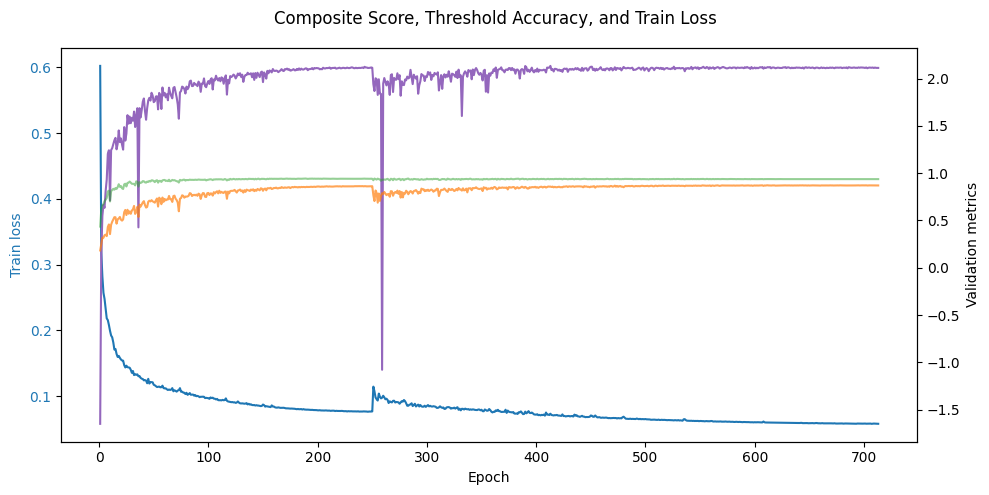

,epoch,train_loss,lr,composite_score,rmse_log,rmse_ms,rmse_percent,median_relative_error,p90_relative_error,p95_relative_error,p99_relative_error,within_10pct,median_ratio_error,p90_ratio_error,p99_ratio_error,within_25pct,within_50pct,within_2x
412,413,0.073167,0.000610,2.133541,0.217264,158.619625,0.374959,0.028192,0.147321,0.314302,0.953040,0.857714,1.028702,1.158933,2.720933,0.937591,0.967893,0.982434
389,390,0.076275,0.000657,2.132160,0.219975,151.947488,0.372936,0.028832,0.146085,0.310784,0.940628,0.854494,1.029340,1.157691,2.684670,0.938031,0.968479,0.983166
525,526,0.062955,0.000341,2.125155,0.213225,151.048672,0.407538,0.028050,0.140781,0.308728,0.965556,0.866107,1.028721,1.151222,2.735184,0.939982,0.968186,0.982531
450,451,0.070001,0.000525,2.124907,0.223484,153.122953,0.377577,0.027614,0.155754,0.330661,0.954349,0.855860,1.027948,1.164707,2.792315,0.934957,0.966136,0.981848
552,553,0.061875,0.000276,2.124004,0.213062,149.917568,0.408194,0.023629,0.139565,0.310239,0.986925,0.869132,1.024020,1.149061,2.715353,0.938616,0.967747,0.982385
449,450,0.070426,0.000527,2.123932,0.222128,151.305639,0.378305,0.027825,0.148731,0.321838,0.984169,0.858105,1.028132,1.160298,2.744587,0.937494,0.966917,0.981995
242,243,0.076583,0.000012,2.123730,0.208753,151.725196,0.405165,0.023643,0.140587,0.290504,0.952221,0.861911,1.024044,1.152170,2.648319,0.941837,0.969308,0.983361
541,542,0.062429,0.000302,2.122791,0.212494,152.658537,0.406576,0.024033,0.144348,0.309431,0.977894,0.866790,1.024439,1.154473,2.737660,0.938616,0.968625,0.982434
570,571,0.061125,0.000235,2.122449,0.213375,153.290459,0.411726,0.020011,0.142077,0.320845,0.980792,0.869523,1.020231,1.152193,2.721345,0.937396,0.967210,0.982434
479,480,0.068577,0.000455,2.122326,0.222414,155.619930,0.374058,0.029220,0.152847,0.322233,0.944975,0.851176,1.029640,1.165408,2.841527,0.936762,0.967600,0.982434


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train loss",
    color="tab:blue",
)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train loss", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(
    history_df["epoch"],
    history_df["composite_score"],
    label="Composite score",
    color="tab:purple",
)
ax2.plot(
    history_df["epoch"],
    history_df["within_10pct"],
    label="Within 10%",
    color="tab:orange",
    alpha=0.7,
)
ax2.plot(
    history_df["epoch"],
    history_df["within_25pct"],
    label="Within 25%",
    color="tab:green",
    alpha=0.5,
)
ax2.set_ylabel("Validation metrics")

fig.suptitle("Composite Score, Threshold Accuracy, and Train Loss")
fig.tight_layout()
plt.show()

history_df.sort_values(
    ["composite_score", "within_10pct", "rmse_percent", "p99_relative_error"],
    ascending=[False, False, True, True],
).head(10)

In [26]:
model.load_state_dict(best_state["model"])
print("Best epoch:", best_state["epoch"])
print("Best composite score:", best_state["val_composite_score"])
print("Best val RMSE:", best_state["val_rmse"])
print("Best val within_10pct:", best_state["val_within_10pct"])
print("Best val within_25pct:", best_state["val_within_25pct"])
print("Best val rmse_percent:", best_state["val_rmse_percent"])
print("Best val p99_relative_error:", best_state["val_p99_relative_error"])

Best epoch: 413
Best composite score: 2.1335413914058536
Best val RMSE: 0.21726381861468338
Best val within_10pct: 0.8577144530106373
Best val within_25pct: 0.9375914901922514
Best val rmse_percent: 0.3749585128723273
Best val p99_relative_error: 0.9530405


In [27]:
val_metrics, val_true_log, val_pred_log = evaluate_mlp(model, val_loader)
test_metrics, test_true_log, test_pred_log = evaluate_mlp(model, test_loader)

pd.DataFrame([val_metrics, test_metrics], index=["val", "test"])

,rmse_log,rmse_ms,rmse_percent,median_relative_error,p90_relative_error,p95_relative_error,p99_relative_error,within_10pct,median_ratio_error,p90_ratio_error,p99_ratio_error,within_25pct,within_50pct,within_2x
val,0.217264,158.619625,0.374959,0.028192,0.147321,0.314302,0.953040,0.857714,1.028702,1.158933,2.720933,0.937591,0.967893,0.982434
test,0.204118,132.463814,0.286531,0.027948,0.141348,0.310609,0.919432,0.864721,1.028575,1.153478,2.742003,0.939400,0.967654,0.982609


# Save Model

In [28]:
from pathlib import Path
import torch

model_dir = Path("/content/drive/MyDrive/Models")
model_dir.mkdir(parents=True, exist_ok=True)

save_path = model_dir / "15.pt"

if "best_state" in globals() and best_state is not None:
    model.load_state_dict(best_state["model"])

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "n_model_features": X_model_train.shape[1],
        "n_hw_features": X_hw_train.shape[1],
        "model_feature_cols": model_feature_cols,
        "hardware_feature_cols": hardware_feature_cols,
        "model_scaler": model_scaler,
        "hw_scaler": hw_scaler,
        "target_col": "log_average_ms",
        "best_val_rmse": best_val_rmse if "best_val_rmse" in globals() else None,
        "best_val_composite_score": best_composite_score if "best_composite_score" in globals() else None,
        "selection_metric": "composite_within_tail",
        "composite_weights": COMPOSITE_WEIGHTS,
        "seed": SEED,
    },
    save_path,
)

print("Saved to:", save_path)

Saved to: /content/drive/MyDrive/Models/15.pt


# Analysis

In [29]:
test_results = test_df.copy()

test_results["pred_log_latency"] = test_pred_log
test_results["true_log_latency"] = test_true_log

test_results["pred_latency_ms"] = np.exp(test_results["pred_log_latency"])
test_results["true_latency_ms"] = np.exp(test_results["true_log_latency"])

test_results["relative_error"] = (
    np.abs(test_results["pred_latency_ms"] - test_results["true_latency_ms"])
    / test_results["true_latency_ms"]
)

In [30]:
def group_latency_metrics(g):
    y_true = g["true_log_latency"].to_numpy()
    y_pred = g["pred_log_latency"].to_numpy()

    true_ms = np.exp(y_true)
    pred_ms = np.exp(y_pred)

    rel_err = np.abs(pred_ms - true_ms) / true_ms

    return pd.Series({
        "count": len(g),
        "rmse_log": np.sqrt(mean_squared_error(y_true, y_pred)),
        "within_10pct": np.mean(rel_err <= 0.10),
        "within_25pct": np.mean(rel_err <= 0.25),
        "within_50pct": np.mean(rel_err <= 0.50),
    })

In [31]:
test_results["abs_log_error"] = np.abs(
    test_results["pred_log_latency"] - test_results["true_log_latency"]
)

test_results.groupby(["cpu_provider", "platform", "num_cores"])["relative_error"].agg(
    count="count",
    median="median",
    p90=lambda x: x.quantile(0.9),
    within_10pct=lambda x: (x <= 0.10).mean(),
    within_25pct=lambda x: (x <= 0.25).mean(),
).reset_index()

,cpu_provider,platform,num_cores,count,median,p90,within_10pct,within_25pct
0,amd,gcloud,1,2621,0.025163,0.091948,0.912247,0.975582
1,amd,gcloud,2,3763,0.040901,0.173004,0.797502,0.953760
2,amd,gcloud,4,2493,0.047404,0.235764,0.738468,0.905335
3,intel,bluehive,1,1347,0.025979,0.093922,0.901262,0.942094
4,intel,bluehive,2,2686,0.023430,0.074123,0.919955,0.940804
5,intel,bluehive,4,3921,0.021960,0.100238,0.899770,0.930120
6,intel,bluehive,8,2347,0.024409,0.104417,0.898168,0.931402
7,intel,gcloud,6,1350,0.025881,0.117773,0.886667,0.927407


In [32]:
test_results.groupby(["cpu_provider", "platform", "num_cores"])["cv"].agg(
    within_10pct=lambda x: (x <= 0.10).mean(),
    count="count",
    median="median",
    p90=lambda x: x.quantile(0.9),
).reset_index()

,cpu_provider,platform,num_cores,within_10pct,count,median,p90
0,amd,gcloud,1,1.0,2621,0.008731,0.026719
1,amd,gcloud,2,1.0,3763,0.029216,0.072814
2,amd,gcloud,4,1.0,2493,0.035029,0.075006
3,intel,bluehive,1,1.0,1347,0.002264,0.006687
4,intel,bluehive,2,1.0,2686,0.004681,0.017785
5,intel,bluehive,4,1.0,3921,0.004827,0.018930
6,intel,bluehive,8,1.0,2347,0.004055,0.015685
7,intel,gcloud,6,1.0,1350,0.007208,0.016773


In [33]:
test_results.groupby(["cpu_provider", "platform", "num_cores"]).apply(
    group_latency_metrics,
    include_groups=False
).reset_index()

,cpu_provider,platform,num_cores,count,rmse_log,within_10pct,within_25pct,within_50pct
0,amd,gcloud,1,2621.0,0.100484,0.912247,0.975582,0.991988
1,amd,gcloud,2,3763.0,0.142483,0.797502,0.953760,0.986181
2,amd,gcloud,4,2493.0,0.186320,0.738468,0.905335,0.964701
3,intel,bluehive,1,1347.0,0.230774,0.901262,0.942094,0.974016
4,intel,bluehive,2,2686.0,0.231728,0.919955,0.940804,0.973194
5,intel,bluehive,4,3921.0,0.227110,0.899770,0.930120,0.948738
6,intel,bluehive,8,2347.0,0.265330,0.898168,0.931402,0.947593
7,intel,gcloud,6,1350.0,0.247118,0.886667,0.927407,0.946667
